<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/4_2_modificar_arquitectura_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2: Modificación de redes neuronales

En este ejercicio entrenarás y modificarás la arquitectura de un modelo de redes neuronales ([restnet-18](https://arxiv.org/pdf/1512.03385)). Completa las secciones indicadas y analiza los resultados obtenidos para evaluar la eficiencia de cada método.

Además, encontrarás partes del código contendrán el comentario de '# ACTIVIDAD' que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique. Finalmente, en el final de este ejercicio, deberás responder a una serie de preguntas.



In [ ]:
import torch
import numpy as np

# Aseguramos que los resultados sean reproducibles
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

## Cargamos dataset

In [ ]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

# Dividir el conjunto de datos en 3 partes
train, validation, test = torch.utils.data.random_split(data, [0.8, 0.1, 0.1])

100%|██████████| 169M/169M [00:02<00:00, 72.4MB/s]


## Creación de la red neuronal

In [ ]:
from torch import nn


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size=3, stride=stride, padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ELU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
        )
        self.downsample = downsample
        self.ELU = nn.ELU()
        self.out_channels = out_channels

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.ELU(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10, in_channels=3):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ELU(),
        )
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer0 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc = nn.Linear(512, num_classes)

        self.dropout = nn.Dropout(p=0.2)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

In [ ]:
def resnet18(layers):
    """Crea un modelo ResNet-18 para clasificación de imágenes de 100 clases para RGB.

    Args:
        layers (list): Lista de capas para cada bloque residual.
        **kwargs: Argumentos adicionales para la clase ResNet.
    """
    return ResNet(ResidualBlock, layers, num_classes=100, in_channels=3)


model = resnet18([2, 2, 2, 2])

## Entrenar el modelo

In [ ]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


def train_model(
    model, train_loader, val_loader, optimizer, criterion=None, device="cpu", epochs=5
):
    """
    Entrenar un modelo con seguimiento de progreso y métricas de precisión.

    Args:
        model: Modelo PyTorch para entrenar
        train_loader: DataLoader para datos de entrenamiento
        val_loader: DataLoader para datos de validación
        optimizer: Optimizador PyTorch
        criterion: Función de loss (por defecto CrossEntropyLoss)
        device: Dispositivo a utilizar ('cpu' o 'cuda')
        epochs: Número de épocas de entrenamiento

    Returns:
        dict: Historial de entrenamiento con métricas
    """
    if criterion is None:
        criterion = torch.nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    model.to(device)
    # Barra de progreso de épocas
    epoch_pbar = tqdm(range(epochs), desc="Épocas")
    for _ in epoch_pbar:
        # Fase de entrenamiento
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        # Barra de progreso de lotes
        batch_pbar = tqdm(train_loader, desc="Entrenamiento", leave=False)
        for images, labels in batch_pbar:
            images = images.to(device)
            labels = labels.to(device)

            # Paso forward + backward + optimización
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calcular exactitud
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Paso hacia atrás y optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Actualizar historial de métricas
            train_loss += loss.item()
            rolling_acc = 100 * correct / total

            batch_pbar.set_postfix(
                {"loss": f"{loss.item():.4f}", "acc": f"{rolling_acc:.2f}%"}
            )

        # Calcular métricas de época
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100 * correct / total
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)

        # Fase de validación
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        val_pbar = tqdm(val_loader, desc="Validación", leave=False)
        for images, labels in val_pbar:
            images = images.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Calcular exactitud
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Actualizar historial de métricas
            val_loss += loss.item()

            # Actualizar barra de progreso
            val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        # Calcular métricas de validación
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100 * correct / total
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        # Actualizar barra de progreso de época
        epoch_pbar.set_postfix(
            {
                "train_loss": f"{epoch_train_loss:.4f}",
                "train_acc": f"{epoch_train_acc:.2f}%",
                "val_loss": f"{epoch_val_loss:.4f}",
                "val_acc": f"{epoch_val_acc:.2f}%",
            }
        )

    return history

In [ ]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True
)

validation_loader = torch.utils.data.DataLoader(
    validation, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    eps=1e-08,
    weight_decay=0,
)

critirion = torch.nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

history = train_model(
    model,
    train_loader,
    validation_loader,
    optimizer,
    criterion=critirion,
    device=device,
    epochs=5,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Épocas:   0%|          | 0/5 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

...

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

## Visualizar progresión del entrenamiento

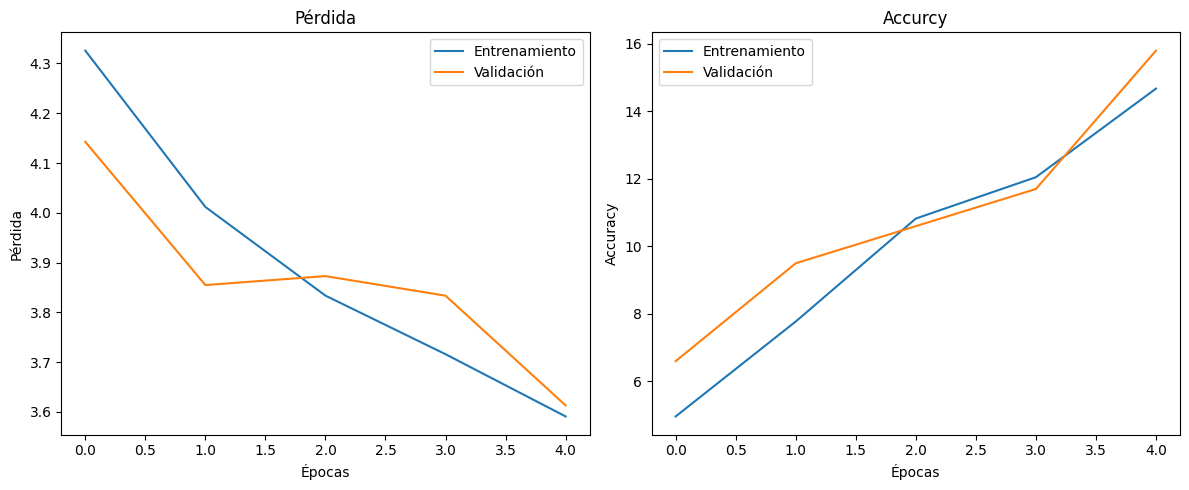

In [ ]:
# ACTIVIDAD: Visualizar la pérdida y la acc. de entrenamiento y validación
def plot_history(history):
    """
    Visualizar el historial de entrenamiento y validación.

    Args:
        history: Diccionario que contiene el historial de entrenamiento
    """
    # Visualizar la pérdida y precisión de entrenamiento y validación
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(history["train_loss"], label="Entrenamiento")
    ax[0].plot(history["val_loss"], label="Validación")
    ax[0].set_title("Pérdida")
    ax[0].set_xlabel("Épocas")
    ax[0].set_ylabel("Pérdida")
    ax[0].legend()

    # ACTIVIDAD: Visualizar la precisión de entrenamiento y validación
    ax[1].plot(history["train_acc"], label="Entrenamiento")
    ax[1].plot(history["val_acc"], label="Validación")
    ax[1].set_title("Accurcy")
    ax[1].set_xlabel("Épocas")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## Evaluar el modelo

In [ ]:
from sklearn.metrics import accuracy_score


# ACTIVIDAD: Evaluar el modelo en el conjunto de prueba
def predict_model(model, test_loader, device="cpu"):
    """
    Predecir etiquetas para un conjunto de datos utilizando un modelo entrenado.

    Args:
        model: Modelo PyTorch para evaluar
        test_loader: DataLoader para datos de prueba
        device: Dispositivo a utilizar ('cpu' o 'cuda')

    Returns:
        list: Lista de etiquetas predichas
        list: Lista de etiquetas verdaderas
    """
    model.eval()
    all_predictions = []
    truth_labels = []

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            truth_labels.extend(labels.cpu().numpy())

    return all_predictions, truth_labels


test_loader = torch.utils.data.DataLoader(
    test, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True
)
predictions, truth_labels = predict_model(model, test_loader, device=device)
accuracy = accuracy_score(truth_labels, predictions)
print(f"Precisión en el conjunto de prueba: {accuracy * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Precisión en el conjunto de prueba: 14.60%


- Prueba modificar el número de canales en las capas convolucionales: cambia la arquitectura para que use [2, 2, 2, 2], [3, 4, 6, 3] vs [1, 1, 1, 1] y compara el tiempo de entrenamiento y la precisión final. ¿Qué arquitectura te da mejores resultados?
  * Resultados en orden: 13.40%, 10.60%, 12.50%
  * Los tiempos son similares, pero cuanto mas canales, más tiempo de entrenamiento.
- Modifica el modelo para que use otra función de activación como SELU y ELU en vez de ReLU. ¿Qué pasa? ¿Cuál es la mejor función de activación para este problema? (usando el mejor modelo de la sección anterior)
  * ReLU: 13.40%
  * SELU: 13.30%
  * ELU: 15.10%
- Modifica el numero de canales de 512 a 256 del ultimo bloque (`self.layer3` y `self.fc`). ¿Qué pasa? (usa el mejor modelo de la sección anterior)
  * El modelo se entrena más rápido, pero la precisión baja a 12.80%. Esto se debe a que el modelo pierde parametros y no puede aprender patrones complejos en los datos.
- Intenta añadir capas de Dropout después de algunas activaciones. ¿Con qué valor de dropout (0.2, 0.5) obtienes mejores resultados? ¿En qué parte de la red es más efectivo colocar estas capas: al principio, en medio o cerca de las capas finales?
  * En general empeora la precisión, pero usar dropout serviría para evitar el sobreajuste en caso de que entrenaramos el modelo por más épocas. Observamos que el dropout es más efectivo en las capas finales, ya que ayuda a evitar el sobreajuste en las últimas capas de la red, donde se encuentran los parámetros más complejos.
- (Difícil) ¿Por qué es importante la normalización? ¿Qué pasaría si no la hiciéramos? ¿Como funcionan los bloques residuales? ¿Por qué son útiles? ¿Qué hace cada capa?
  * La normalización ayuda a estabilizar el aprendizaje y a acelerar la convergencia. Sin normalización, los gradientes pueden volverse muy grandes o muy pequeños, lo que puede dificultar el entrenamiento de la red (esto se conoce como el problema de la explosión o desaparición del gradiente). La normalización también ayuda a que las activaciones de las neuronas tengan una media cercana a cero y una varianza cercana a uno, lo que puede mejorar la eficiencia del entrenamiento.
  * Los bloques residuales son una técnica utilizada en redes neuronales profundas para facilitar el entrenamiento de modelos con muchas capas. La idea principal es que, en lugar de aprender la función de mapeo directa entre la entrada y la salida, la red aprende la diferencia entre la entrada y la salida deseada. Esto se logra mediante la adición de conexiones de salto (skip connections) que permiten que la información fluya a través de la red sin ser alterada por las capas intermedias. Esto ayuda a evitar el problema de la desaparición del gradiente y permite entrenar redes más profundas sin que se degrade el rendimiento.
  * La arquitectura de la red neuronal se basa en bloques residuales, que permiten el paso de información a través de la red sin que se vea afectada por las capas intermedias. Esto ayuda a evitar el problema de la desaparición del gradiente y permite entrenar redes más profundas. Nuestra red esta compuesta de 4 bloques residuales, cada uno con 2 capas convolucionales y una capa de normalización. Cada bloque tiene un número diferente de canales, lo que permite capturar diferentes características de la imagen. La red también incluye capas de activación (ReLU) y capas de normalización (BatchNorm) para mejorar la eficiencia del entrenamiento.

**Nota:** Todas las funciones de activación y capas de normalización están disponibles usando el módulo `nn` de PyTorch. Puedes consultar la [documentación](https://pytorch.org/docs/stable/nn.html) para más detalles.